<a href="https://colab.research.google.com/github/GustavoBLuz/Projetos_Aula/blob/Ci%C3%AAncia_de_Dados_ProjetoFraudes_Cart%C3%A3oCredito/V6_Oversampling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ---------------------- INTRODUÇÃO ----------------------

O objetivo deste script é desenvolver, treinar e avaliar um modelo Machine Learning capaz de detectar fraudes bancárias de cartão de crédito. Nossa variavel alvo para isso é a fraud_bool, considerando 1 para fraude e 0 para uma transação legítima.
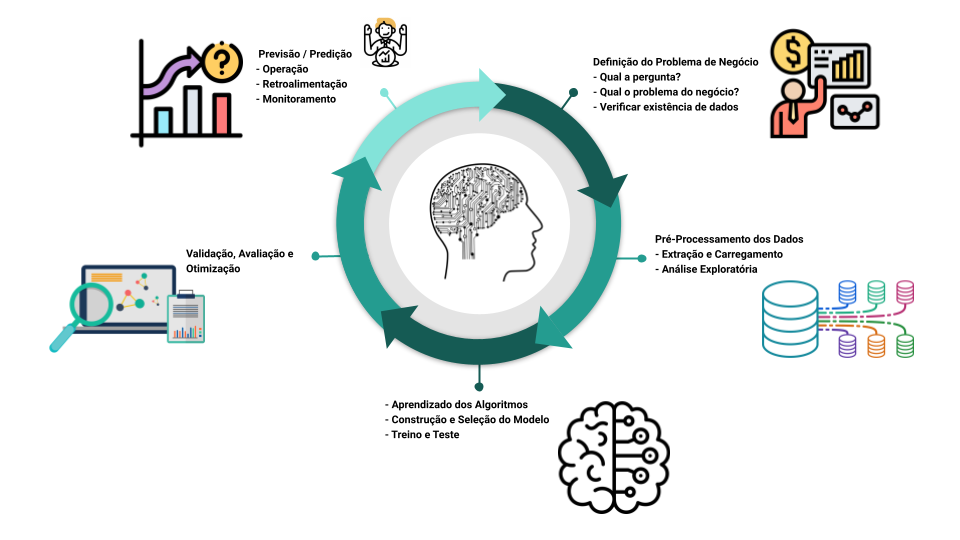

# ---------------------- IMPORTAÇÃO/BIBLIOTECA ----------------------

# ---------------------- VARIAVEL ALVO: fraud_bool ----------------------

*    ***fraud_bool*** : Variável binária (0 ou 1) que indica se a transação (ou solicitação) é fraudulenta (1) ou legítima (0).

*   prev_address_months_count: Tempo (em meses) que o cliente ficou no endereço anterior.

*   current_address_months_count: Tempo (em meses) que o cliente está no endereço atual.

*   zip_count_4w: Número de códigos postais (CEP) diferentes usados nas últimas 4 semanas — pode indicar comportamento suspeito se for alto.

*   bank_branch_count_8w: Número de agências bancárias diferentes usadas nas últimas 8 semanas.

*   housing_status: Situação da moradia do cliente (ex: próprio, alugado, com * parentes).

*   name_email_similarity: Métrica de similaridade entre o nome do cliente e o e-mail cadastrado (valores mais baixos podem indicar fraude).

*   email_is_free: Indica se o e-mail é de um provedor gratuito (ex: Gmail, Yahoo).

*   phone_home_valid: Validação do número de telefone fixo (1 = válido, 0 = inválido).

*   phone_mobile_valid: Validação do número de celular.

*   contacto: Variável genérica — pode representar dados de contato como telefone, e-mail etc. (confirme na base se o nome está correto).

*   income: Renda do cliente.

*   credit_risk_score: Score de risco de crédito do cliente (quanto maior, menor o risco normalmente).

*   proposed_credit_limit: Limite de crédito proposto para o cliente.

*   has_other_cards: Indica se o cliente possui outros cartões de crédito (1 = sim, 0 = não).

*   bank_months_count: Tempo (em meses) que o cliente tem conta no banco.

*   customer_age: Idade do cliente.

*   employment_status: Situação empregatícia (empregado, desempregado, estudante etc).

*   date_of_birth_distinct_emails_4w: Número de e-mails diferentes usados por clientes com a mesma data de nascimento nas últimas 4 semanas — pode indicar fraude em massa.

*   days_since_request: Dias desde a solicitação do crédito.

*   intended_balcon_amount: Valor que o cliente pretende colocar em balcão (ou solicitar).

*   payment_type: Tipo de pagamento (ex: boleto, débito, cartão de crédito).

*   foreign_request: Indica se a solicitação foi feita de fora do país (1 = sim, 0 = não).

*   source (object): Fonte da requisição — pode ser o canal usado (ex: web, mobile).

*   session_length_in_minutes: Duração da sessão em minutos.

*   device_os (object): Sistema operacional do dispositivo (ex: Android, iOS, Windows).

*   keep_alive_session: Indica se a sessão ficou ativa por tempo prolongado (1 = sim).

*   device_distinct_emails_8w: Número de e-mails diferentes usados no mesmo dispositivo nas últimas 8 semanas.

*   device_fraud_count: Quantidade de fraudes conhecidas associadas ao dispositivo.

*   velocity_6h: Número de tentativas/sessões do cliente nas últimas 6 horas.

*   velocity_24h: Número de tentativas/sessões nas últimas 24 horas.

*   velocity_4w: Número de tentativas/sessões nas últimas 4 semanas.

*   month: Mês da solicitação ou da transação — pode ser útil para detectar padrões sazonais de fraude.

In [ ]:
# Importações essenciais
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn as sl
import warnings
import csv
import os
import time
import matplotlib.patches as patches
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, accuracy_score, RocCurveDisplay, roc_auc_score, classification_report
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import LabelEncoder

# Instalar a biblioteca imbalanced-learn // já está satisfeito as condições
# %pip install imbalanced-learn // já está satisfeito as condições

# --- Aplicar Undersampling (RandomUnderSampler) e separar dados removidos ---
from imblearn.under_sampling import RandomUnderSampler

In [ ]:
# ==============================================================================
# FUNÇÃO AUXILIAR PARA CALCULAR PREVALÊNCIA
# ==============================================================================

def calcula_prevalencia(y_actual):
    """Calcula a prevalência da classe positiva (fraud_bool = 1)"""
    return sum(y_actual) / len(y_actual)

# ---------------------- IMPORTA/LÊ O CSV ----------------------

In [ ]:
# Carrega o dataset do mesmo caminho usado no notebook de trabalho.
dataset_path = "creditcard_data.csv"

# lê o arquivo csv com o dataset baixado da https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud?resource=download
df = pd.read_csv('creditcard_data.csv')

# ---------------------- DADOS UTILIZADOS ----------------------

Este projeto utiliza um dataset real exatos 1 milhão de dados com 32 colunas de informações sobre o cliente tanto irrelevantes quanto muito relevantes para este teste, uma delas sendo a nossa variavel alvo fraud_bool.
Como é comum que bancos tenham um sistema de dados desbalanceado, com poucos exemplos de fraudes se comparado as operações que são normais do dia a dia.

In [ ]:
print('DataFrame carregado com forma:', df.shape)
display(df.head())
display(df.describe())

DataFrame carregado com forma: (1000000, 32)


,fraud_bool,income,name_email_similarity,prev_address_months_count,current_address_months_count,customer_age,days_since_request,intended_balcon_amount,payment_type,zip_count_4w,...,has_other_cards,proposed_credit_limit,foreign_request,source,session_length_in_minutes,device_os,keep_alive_session,device_distinct_emails_8w,device_fraud_count,month
0,0,0.3,0.986506,-1,25,40,0.006735,102.453711,AA,1059,...,0,1500.0,0,INTERNET,16.224843,linux,1,1,0,0
1,0,0.8,0.617426,-1,89,20,0.010095,-0.849551,AD,1658,...,0,1500.0,0,INTERNET,3.363854,other,1,1,0,0
2,0,0.8,0.996707,9,14,40,0.012316,-1.490386,AB,1095,...,0,200.0,0,INTERNET,22.730559,windows,0,1,0,0
3,0,0.6,0.475100,11,14,30,0.006991,-1.863101,AB,3483,...,0,200.0,0,INTERNET,15.215816,linux,1,1,0,0
4,0,0.9,0.842307,-1,29,40,5.742626,47.152498,AA,2339,...,0,200.0,0,INTERNET,3.743048,other,0,1,0,0


,fraud_bool,income,name_email_similarity,prev_address_months_count,current_address_months_count,customer_age,days_since_request,intended_balcon_amount,zip_count_4w,velocity_6h,...,phone_mobile_valid,bank_months_count,has_other_cards,proposed_credit_limit,foreign_request,session_length_in_minutes,keep_alive_session,device_distinct_emails_8w,device_fraud_count,month
count,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1.000000e+06,1000000.000000,1000000.000000,1000000.000000,...,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.0,1000000.000000
mean,0.011029,0.562696,0.493694,16.718568,86.587867,33.689080,1.025705e+00,8.661499,1572.692049,5665.296605,...,0.889676,10.839303,0.222988,515.851010,0.025242,7.544940,0.576947,1.018312,0.0,3.288674
std,0.104438,0.290343,0.289125,44.046230,88.406599,12.025799,5.381835e+00,20.236155,1005.374565,3009.380665,...,0.313293,12.116875,0.416251,487.559902,0.156859,8.033106,0.494044,0.180761,0.0,2.209994
min,0.000000,0.100000,0.000001,-1.000000,-1.000000,10.000000,4.036860e-09,-15.530555,1.000000,-170.603072,...,0.000000,-1.000000,0.000000,190.000000,0.000000,-1.000000,0.000000,-1.000000,0.0,0.000000
25%,0.000000,0.300000,0.225216,-1.000000,19.000000,20.000000,7.193246e-03,-1.181488,894.000000,3436.365848,...,1.000000,-1.000000,0.000000,200.000000,0.000000,3.103053,0.000000,1.000000,0.0,1.000000
50%,0.000000,0.600000,0.492153,-1.000000,52.000000,30.000000,1.517574e-02,-0.830507,1263.000000,5319.769349,...,1.000000,5.000000,0.000000,200.000000,0.000000,5.114321,1.000000,1.000000,0.0,3.000000
75%,0.000000,0.800000,0.755567,12.000000,130.000000,40.000000,2.633069e-02,4.984176,1944.000000,7680.717827,...,1.000000,25.000000,0.000000,500.000000,0.000000,8.866131,1.000000,1.000000,0.0,5.000000
max,1.000000,0.900000,0.999999,383.000000,428.000000,90.000000,7.845690e+01,112.956928,6700.000000,16715.565404,...,1.000000,32.000000,1.000000,2100.000000,1.000000,85.899143,1.000000,2.000000,0.0,7.000000


A preperação dos dados a cima incluem seleção das variaveis relevantes para o problema da fraude, removendo alguns atributos com baixa contribuição para o modelo ou que não estejam presentes em um cenário real.

Há tambem o tratamento deles para que o ML consiga entender e ler, transformando tudo que há nas informações, incluindo nomes, em números para serem lidos.

# ---------------------- CONTAGEM ANTES DO TREINO ---------------------------

In [ ]:
# Conta os valores únicos
fraud_counts = df['fraud_bool'].value_counts()
print(fraud_counts)

# Adiciona os counts de 'fraud_bool' em uma variável de lista
# Garantindo que a ordem seja [count_for_0, count_for_1]
count_list_pre = [fraud_counts.get(0, 0), fraud_counts.get(1, 0)]
print(f"Counts em lista: {count_list_pre}")

fraud_bool
0    988971
1     11029
Name: count, dtype: int64
Counts em lista: [np.int64(988971), np.int64(11029)]


Colocando as amostras aleatorias + Ajustando os indices

In [ ]:
# Gerando amostras aleatórias dos dados
df = df.sample(n = len(df))
# Ajustando os índices do dataset
df= df.reset_index(drop = True)

In [ ]:
#Separar features e target
target_col = 'fraud_bool' # Set target to fraud_bool
if target_col not in df.columns:
    # tentativa automática: se existir uma coluna chamada 'label' ou a última coluna, use-a
    if 'label' in df.columns:
        target_col = 'label'
    else:
        target_col = df.columns[-1]
print('Usando coluna alvo:', target_col)

Usando coluna alvo: fraud_bool


# ---------------------- SEPARAÇÃO 70/15/15 ----------------------------

A divisão dos dados é feita entre Treino, Validação e Teste, feita em camadas para preservar propoções de fraude.

In [ ]:
#Nova utilização de Split //Ainda em teste
df_treino, df_temp = train_test_split(df, test_size=0.30, stratify=df['fraud_bool'], random_state=42)
len(df_treino)

700000

In [ ]:
# Dados de teste
df_valid, df_teste = train_test_split(df_temp, test_size=0.50, stratify=df_temp['fraud_bool'], random_state=42)
len(df_teste)
len(df_valid)

150000

In [ ]:
# Verifica se as amostras somadas totalizam o volume original dos dados
print('Todas as amostras (n = %d)'%len(df))
assert len(df) == (len(df_teste) + len(df_valid) + len(df_treino)), 'algo'

# Verifica a prevalência da classe positiva em cada subconjunto
print("\nTreino(n = %d): %.3f" % (len(df_treino), calcula_prevalencia(df_treino.fraud_bool.values)))
print("Validação(n = %d): %.3f" % (len(df_valid), calcula_prevalencia(df_valid.fraud_bool.values)))
print("Teste(n = %d): %.3f" % (len(df_teste), calcula_prevalencia(df_teste.fraud_bool.values)))

Todas as amostras (n = 1000000)

Treino(n = 700000): 0.011
Validação(n = 150000): 0.011
Teste(n = 150000): 0.011


In [ ]:
X_train = df_treino.drop(columns=['fraud_bool'])
y_train = df_treino['fraud_bool']
X_val = df_valid.drop(columns=['fraud_bool'])
y_val = df_valid['fraud_bool']
X_test = df_teste.drop(columns=['fraud_bool'])
y_test = df_teste['fraud_bool']

# ---------------------- REALIZA OVERSSAMPLING ---------------------
Utilizando o balanceamento do SMOTE para a classe minotirária, ela gera exemplos sintéticos de fraudes para evitar viés e melhorar a capacidade do modelo na detectação das mesmas.

In [ ]:
#Converter colunas categóricas para números
# Isso é necessário porque o SMOTE só funciona com dados numéricos.
# Aqui cada coluna com texto (ex.: 'AB', 'F', 'Sim', 'Não', etc.) é convertida automaticamente para valores inteiros.
label_encoders = {}

for col in X_train.columns:
    if X_train[col].dtype == "object":  #Aqui detecta colunas categóricas
        le = LabelEncoder()
        X_train[col] = le.fit_transform(X_train[col].astype(str))
        X_test[col] = le.transform(X_test[col].astype(str))
        label_encoders[col] = le        #Salva o encoder caso precise inverter depois

#Aplicar SMOTE
#Esta é a parte diretamente responsável pela melhora da acurácia.
#O SMOTE gera exemplos sintéticos da classe minoritária evitando que o modelo fique enviesado e melhorando o aprendizado geral.

sm = SMOTE(random_state=42, sampling_strategy='auto')
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

# ---------------- REMOVE COLUNAS 'INUTEIS' -------------------
Aqui as colunas são removidas utilizando como metrica a utilidade dela para o código e calculo final, as seguintes justificativas foi o que nos levou a remoção:
- Contacto = Contato do usuário, não é relevante ter ou não para saber se é uma transação de fraude.
- phone_home_valid = Similar ao Conctacto, mas para o telefone de casa.
- housing_status = Apesar de saber se o cliente possui casa propria ou alugada pode influenciar na sua linha de crédito, ela não influenciam significativamente o ato em sí da fraude, já que o importante é o comportamento na hora da transação e não na vida socioeconomica de longo prazo.
- employment_status = Mesmo que housing_status
- payment_type = Esta apesar de ajudar, pode mais atrapalhar do que de fato ajudar, as fraudes lidas nos dados é capturado por outras features mais eficazes que esta, causando redundancia e possivelmente desvirtuando o modelo.
- intended_balcon_amout = Esta variavel mostra o valor solicidato e intencional, não o valor REAL DA TRANSAÇÃO, que está ligada a proposed_credit_limit, tornando-a redundante para o código.
-has_other_cards = Ter mais de um cartão não é relevante para a fraude, e sim para o a linha de credito e risco de credito, um fraudador pode ou não ter vários cartões, assim como um usuário legitimo.
-velocity e variantes = Variaveis que possuem um prazo, seja por 6 horas ou 24 horas, não seria algo que utilzaria no momento da checkagem em uma situação real, portanto, foram ignoradas no modelo.


Resumo da opera:
As variaveis removidas foram baseadas em uso para risco/linha de crédito, informações necessárias para o banco gerenciar a conta do cliente mas não são necessárias para a detectação de fraude, já que qualquer um pode ser uma vitima ou atuante.

In [ ]:
# Lista de colunas a serem removidas conforme solicitação do usuário.
columns_to_drop = [
    'contacto',
    'housing_status',
    'employment_status',
    'payment_type',
    'intended_balcon_amount',
    'has_other_cards',
    'velocity_4w',
    'velocity_24h',
    'velocity_6h',
    'device_distinct_emails_8w',
    'keep_alive_session',
    'session_length_in_minutes',
    'date_of_birth_distinct_emails_4w',
    'customer_age',
    'proposed_credit_limit',
    'bank_branch_count_8w'
]

# Salva as colunas a serem removidas em novas variáveis para uso futuro.
# Verifica quais colunas de `columns_to_drop` realmente existem em X_train_res e X_val antes de tentar selecioná-las.
existing_cols_train_res = [col for col in columns_to_drop if col in X_train_res.columns]
existing_cols_val = [col for col in columns_to_drop if col in X_val.columns]

removed_features_train = X_train_res[existing_cols_train_res].copy()
removed_features_val = X_val[existing_cols_val].copy()

# Remove as colunas especificadas dos conjuntos de treino e validação.
X_train_res = X_train_res.drop(columns=columns_to_drop, errors='ignore')
X_val = X_val.drop(columns=columns_to_drop, errors='ignore')

# ----------------------TREINAMENTO DO MODELO----------------------

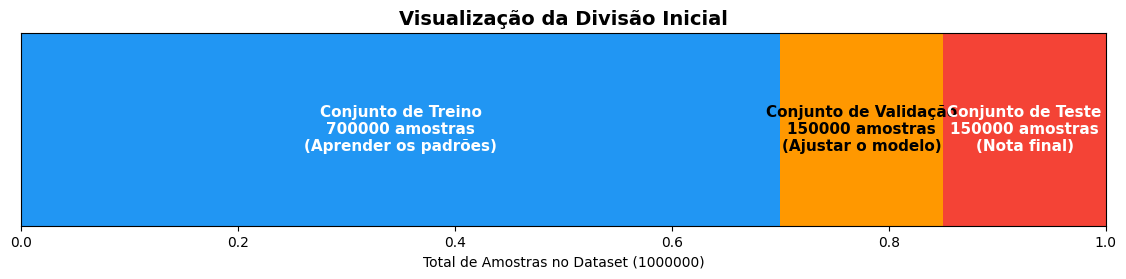

In [ ]:
# ------------------------------------------------------------------
# VISUALIZAÇÃO GRÁFICA DA DIVISÃO (proporções ilustradas)
# ------------------------------------------------------------------


# Calcula proporções com base nas divisões reais
total_samples = len(df) # Usar o tamanho do DataFrame original
train_size_orig = len(df_treino)
validation_size_orig = len(df_valid)
test_size_orig = len(df_teste)

train_ratio = train_size_orig / total_samples
validation_ratio = validation_size_orig / total_samples
test_ratio = test_size_orig / total_samples

# Criando a figura
fig, ax = plt.subplots(1, figsize=(14, 2.5))

# Desenhando os blocos conforme as PROPORÇÕES
current_position = 0

# Treino
ax.add_patch(patches.Rectangle((current_position, 0), train_ratio, 1, facecolor='#2196F3', label=f'Treino ({train_ratio*100:.0f}%)'))
ax.text(current_position + train_ratio / 2, 0.5, f'Conjunto de Treino\n{train_size_orig} amostras\n(Aprender os padrões)', ha='center', va='center', color='white', fontsize=11, weight='bold')
current_position += train_ratio

# Validação
ax.add_patch(patches.Rectangle((current_position, 0), validation_ratio, 1, facecolor='#FF9800', label=f'Validação ({validation_ratio*100:.0f}%)'))
ax.text(current_position + validation_ratio / 2, 0.5, f'Conjunto de Validação\n{validation_size_orig} amostras\n(Ajustar o modelo)', ha='center', va='center', color='black', fontsize=11, weight='bold')
current_position += validation_ratio

# Teste
ax.add_patch(patches.Rectangle((current_position, 0), test_ratio, 1, facecolor='#F44336', label=f'Teste ({test_ratio*100:.0f}%)'))
ax.text(current_position + test_ratio / 2, 0.5, f'Conjunto de Teste\n{test_size_orig} amostras\n(Nota final)', ha='center', va='center', color='white', fontsize=11, weight='bold')

# Configurações do gráfico
ax.set_xlim(0, 1) # Agora o limite é de 0 a 1 (proporções)
ax.set_ylim(0, 1)
ax.set_yticks([])
ax.set_xlabel(f'Total de Amostras no Dataset ({total_samples})')
ax.set_title('Visualização da Divisão Inicial', fontsize=14, weight='bold')

plt.show()

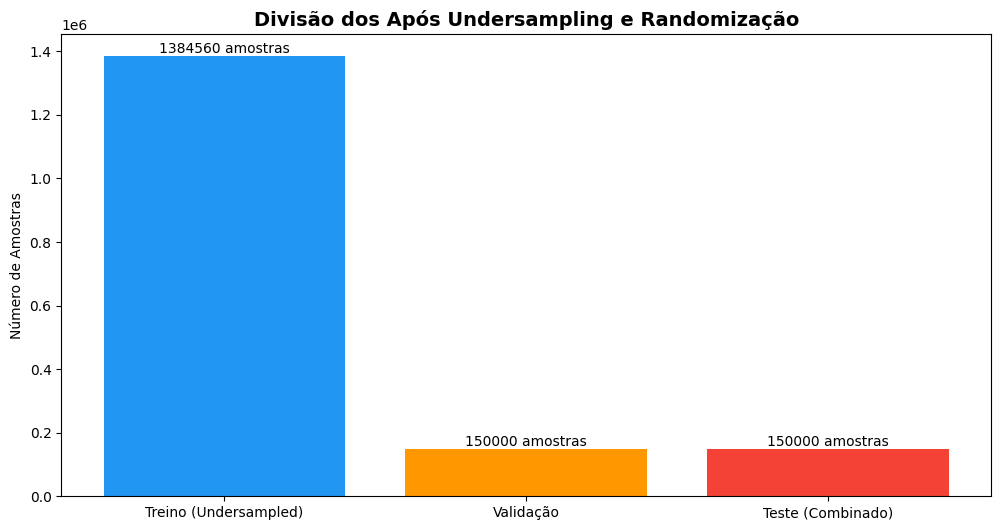

In [ ]:
# ------------------------------------------------------------------
# VISUALIZAÇÃO DA DIVISÃO APÓS COMBINAÇÃO DO TESTE
# ------------------------------------------------------------------
labels = ['Treino (Undersampled)', 'Validação', 'Teste (Combinado)']
sizes = [len(X_train_res), len(X_val), len(X_test)]
colors = ['#2196F3', '#FF9800', '#F44336']

plt.figure(figsize=(12, 6))
bars = plt.bar(labels, sizes, color=colors)
plt.ylabel('Número de Amostras')
plt.title('Divisão dos Após Undersampling e Randomização', fontsize=14, weight='bold')


# Adicionando os valores no topo das barras
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 2, f'{yval} amostras', ha='center', va='bottom')

plt.show()

In [ ]:
# Identifica as colunas categóricas que precisam de codificação.
# Baseado na descrição do problema e nos tipos de dados, sem as colunas removidas.
categorical_cols = []

# Verificar se alguma das colunas restantes é categórica e adicioná-la à lista
# Por exemplo, 'source' e 'device_os' continuam sendo candidatas categóricas se não foram removidas
if 'source' in X_train_res.columns: # Mantém 'source' se não foi removido na lista acima
    categorical_cols.append('source')
if 'device_os' in X_train_res.columns: # Mantém 'device_os' se não foi removido na lista acima
    categorical_cols.append('device_os')

# ----------------------PRINCIPAIS ANÁLISES ----------------------
Durante a exploração e analise de dados, foi realizado uma análise de distribuiição da variavel-alvo e que havia um desbalanceamento, onde então foi aplicado SMOTE.
Logo abaixo é apresentado o F-score, Acurracy, precisão, e posto em um csv.

In [ ]:
# Aplica Label Encoding às colunas categóricas em X_train_res e X_val.
# Cria um dicionário para armazenar os encoders para consistência entre os conjuntos de treino/validação/teste.
label_encoders = {}

for col in categorical_cols:
    # Verifica se a coluna existe em X_train_res (features)
    if col in X_train_res.columns:
        le = LabelEncoder()
        # Ajusta o encoder à coluna do conjunto de treino e transforma os dados.
        X_train_res[col] = le.fit_transform(X_train_res[col])
        label_encoders[col] = le # Armazena o encoder ajustado.

        # Transforma a coluna correspondente no conjunto de validação.
        if col in X_val.columns:
            # Lida com potenciais rótulos não vistos nos dados de validação.
            # Cria um mapeamento para rótulos conhecidos e um padrão para os desconhecidos.
            # Esta abordagem é mais segura caso novas categorias apareçam.
            mapping = {label: idx for idx, label in enumerate(le.classes_)}
            # Se uma categoria em X_val não estiver em le.classes_, atribui um novo inteiro único (ex: len(le.classes_))
            X_val[col] = X_val[col].apply(lambda x: mapping.get(x, len(le.classes_)))
        else:
            print(f"Aviso: A coluna '{col}' não foi encontrada em X_val. Ignorando codificação para esta coluna no conjunto de validação.")
    else:
        print(f"Aviso: A coluna '{col}' não foi encontrada em X_train_res. Ignorando codificação para esta coluna.")

In [ ]:
# --- Treinamento do modelo (RandomForestClassifier) ---

# A lista 'columns_to_handle' e a criação de 'removed_features_train/val' já foram feitas na célula anterior.
# Aqui, vamos focar na identificação e codificação das colunas categóricas PRESENTES nos DataFrames.

# Identifica as colunas categóricas que precisam de codificação.
# Explicitamente listamos as colunas que esperamos que sejam categóricas e as convertemos para str.
intended_categorical_cols = [
    'contacto', 'housing_status', 'employment_status', 'payment_type',
    'source', 'device_os'
]

# Converter colunas para tipo 'object' (string) para garantir que LabelEncoder possa agir.
for col in intended_categorical_cols:
    if col in X_train_res.columns:
        X_train_res[col] = X_train_res[col].astype(str)
    if col in X_val.columns:
        X_val[col] = X_val[col].astype(str)

# Agora, constrói a lista de categorical_cols baseado nas que realmente existem e foram convertidas.
categorical_cols = [col for col in intended_categorical_cols if col in X_train_res.columns]

# Aplica Label Encoding às colunas categóricas em X_train_res e X_val.
# Cria um dicionário para armazenar os encoders para consistência entre os conjuntos de treino/validação/teste.
label_encoders = {}

for col in categorical_cols:
    # Verifica se a coluna existe em X_train_res (features)
    if col in X_train_res.columns:
        le = LabelEncoder()
        # Ajusta o encoder à coluna do conjunto de treino e transforma os dados.
        X_train_res[col] = le.fit_transform(X_train_res[col])
        label_encoders[col] = le # Armazena o encoder ajustado.

        # Transforma a coluna correspondente no conjunto de validação.
        if col in X_val.columns:
            # Lida com potenciais rótulos não vistos nos dados de validação.
            # Cria um mapeamento para rótulos conhecidos e um padrão para os desconhecidos.
            # Esta abordagem é mais segura caso novas categorias apareçam.
            mapping = {label: idx for idx, label in enumerate(le.classes_)}
            # Se uma categoria em X_val não estiver em le.classes_, atribui um novo inteiro único (ex: len(le.classes_))
            X_val[col] = X_val[col].apply(lambda x: mapping.get(x, len(le.classes_)))
        else:
            print(f"Aviso: A coluna '{col}' não foi encontrada em X_val. Ignorando codificação para esta coluna no conjunto de validação.")
    else:
        print(f"Aviso: A coluna '{col}' não foi encontrada em X_train_res. Ignorando codificação para esta coluna.")

# Garante que todas as colunas sejam numéricas após a codificação.
# É uma boa prática garantir que os dtypes sejam numéricos antes de alimentar o modelo.
X_train_res = X_train_res.apply(pd.to_numeric, errors='coerce')
X_val = X_val.apply(pd.to_numeric, errors='coerce')

# Preenche quaisquer NaNs criados por 'coerce' ou categorias não vistas (se houver).
# Estratégias comuns: preencher com 0, média ou mediana. Aqui, preenchemos com 0 para simplicidade.
X_train_res = X_train_res.fillna(0)
X_val = X_val.fillna(0)

# Inicializa e treina o modelo RandomForestClassifier.
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train_res, y_train_res)

# Avalia o modelo no conjunto de validação.
y_val_pred = clf.predict(X_val)
val_acc = accuracy_score(y_val, y_val_pred)
print('\nValidação - Acurácia:', val_acc)
print('\nRelatório de Classificação (validação):\n', classification_report(y_val, y_val_pred))


Validação - Acurácia: 0.9886533333333334

Relatório de Classificação (validação):
               precision    recall  f1-score   support

           0       0.99      1.00      0.99    148345
           1       0.00      0.00      0.00      1655

    accuracy                           0.99    150000
   macro avg       0.49      0.50      0.50    150000
weighted avg       0.98      0.99      0.98    150000



# ---------------------- ENVIA DADOS PARA UM CSV ----------------------

In [ ]:
# Combinar as features e o target em um único DataFrame, mantendo o índice original
df_undersampled = X_train_res.copy()
df_undersampled['fraud_bool'] = y_train_res

# Reordenar o DataFrame de acordo com o índice original para manter a ordem
df_undersampled = df_undersampled.sort_index()

# Salvar o DataFrame em um arquivo CSV
output_csv_path = "undersampled_data.csv"
df_undersampled.to_csv(output_csv_path)

print(f"Dados após undersampling salvos em: {output_csv_path}")
display(df_undersampled.head())

Dados após undersampling salvos em: undersampled_data.csv


,income,name_email_similarity,prev_address_months_count,current_address_months_count,days_since_request,zip_count_4w,credit_risk_score,email_is_free,phone_home_valid,phone_mobile_valid,bank_months_count,foreign_request,source,device_os,device_fraud_count,month,fraud_bool
0,0.8,0.381005,10,3,0.017494,1384,107,0,0,1,-1,0,0,2,0,2,0
1,0.7,0.167401,-1,36,0.012469,1040,115,1,0,1,1,0,0,0,0,3,0
2,0.6,0.642095,-1,64,0.042179,1105,87,1,0,1,20,0,0,1,0,5,0
3,0.8,0.612786,-1,196,0.010300,1541,56,0,0,1,31,0,0,0,0,1,0
4,0.7,0.929214,-1,13,0.004268,3029,107,1,0,1,31,0,0,0,0,2,0


# ---------------------- CONTAGEM PÓS-TREINO DAS VARIAVEIS --------------------

In [ ]:
# Conta os valores únicos
fraud_counts = df_undersampled['fraud_bool'].value_counts()
print(fraud_counts)
# Adiciona os counts de 'fraud_bool' em uma variável de lista
# Garantindo que a ordem seja [count_for_0, count_for_1]
count_list_pos = [fraud_counts.get(0, 1), fraud_counts.get(0, 1)]
print(f"Counts em lista: {count_list_pos}")

fraud_bool
0    692280
1    692280
Name: count, dtype: int64
Counts em lista: [np.int64(692280), np.int64(692280)]


# ---------------------- ENVIA RESULTADOS PARA UM CSV ----------------------


--- AVALIAÇÃO FINAL DO MODELO --- 

Resultados salvos em: resultados_dados.csv

Acurácia Final (no conjunto de teste): 96.98%

Relatório de Classificação Detalhado:
               precision    recall  f1-score   support

           0       0.99      0.98      0.98    148346
           1       0.06      0.12      0.08      1654

    accuracy                           0.97    150000
   macro avg       0.53      0.55      0.53    150000
weighted avg       0.98      0.97      0.97    150000

Matriz de Confusão:


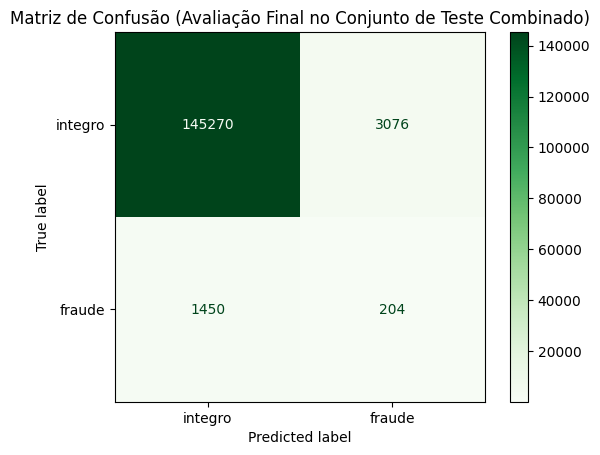


--- AMBIENTE DE INFERÊNCIA CONCLUÍDO ---


In [ ]:
# ------------------------------------------------------------------
# AVALIAÇÃO FINAL E EXPORTAÇÃO PARA CSV
# ------------------------------------------------------------------
print("\n--- AVALIAÇÃO FINAL DO MODELO --- ")

# Replicar as etapas de pré-processamento aplicadas a X_train_res e X_val em X_test

# 1. Definir novamente as colunas categóricas (precisam ser as mesmas usadas no treino)
intended_categorical_cols = [
    'contacto', 'source', 'device_os'
]

# Converter colunas para tipo 'object' (string) em X_test se existirem
for col in intended_categorical_cols:
    if col in X_test.columns:
        X_test[col] = X_test[col].astype(str)

categorical_cols_test = [col for col in intended_categorical_cols if col in X_test.columns]

# Aplica Label Encoding às colunas categóricas em X_test usando os ENCODERS JÁ AJUSTADOS
for col in categorical_cols_test:
    if col in X_test.columns and col in label_encoders: # Verifica se a coluna existe e se há um encoder ajustado para ela
        le = label_encoders[col] # Usa o encoder já ajustado do treino
        # Lida com potenciais rótulos não vistos nos dados de teste.
        mapping = {label: idx for idx, label in enumerate(le.classes_)}
        X_test[col] = X_test[col].apply(lambda x: mapping.get(x, len(le.classes_))) # Atribui novo inteiro para desconhecidos
    elif col in X_test.columns:
        print(f"Aviso: A coluna '{col}' está em X_test mas não foi encontrada um encoder ajustado. Ignorando codificação.")

# Garante que todas as colunas sejam numéricas após a codificação.
X_test = X_test.apply(pd.to_numeric, errors='coerce')

# Preenche quaisquer NaNs criados por 'coerce' ou categorias não vistas (se houver).
X_test = X_test.fillna(0)

# Garante que a ordem das colunas em X_test seja a mesma que em X_train_res
# Isso é crucial para que o modelo funcione corretamente
missing_cols_in_test = set(X_train_res.columns) - set(X_test.columns)
for c in missing_cols_in_test:
    X_test[c] = 0 # Adiciona colunas ausentes no teste e preenche com 0 (ou outro valor padrão)
X_test = X_test[X_train_res.columns]

# 1. Realizar previsões no conjunto de teste
y_test_pred = clf.predict(X_test)

# 2. Calcular as métricas solicitadas
# Métricas gerais
accuracy_overall = accuracy_score(y_test, y_test_pred)
tn, fp, fn, tp = confusion_matrix(y_test, y_test_pred).ravel()
specificity = tn / (tn + fp) if (tn + fp) != 0 else 0 # Specificity é o Recall da classe negativa (classe 0)

# Métricas para a Classe 1 (Fraude)
precision_1 = precision_score(y_test, y_test_pred, pos_label=1, zero_division=0)
recall_1 = recall_score(y_test, y_test_pred, pos_label=1, zero_division=0)
f1_score_1 = f1_score(y_test, y_test_pred, pos_label=1, zero_division=0)

# Métricas para a Classe 0 (Não Fraude)
precision_0 = precision_score(y_test, y_test_pred, pos_label=0, zero_division=0)
recall_0 = recall_score(y_test, y_test_pred, pos_label=0, zero_division=0)
f1_score_0 = f1_score(y_test, y_test_pred, pos_label=0, zero_division=0)

# 3. Definir os campos para o CSV e as linhas de dados
fields = ['Modelo', 'Descrição', 'Acurácia', 'Precisão', 'Recall', 'Specificity', 'F1 Score', 'Tempo em Segundo']
model_name = "RandomForestClassifier_Undersampled"
time_in_seconds = 0.0 # Placeholder

# Linha de dados para a Classe 1 (Fraud_bool = 1)
data_row_1 = [
    model_name,
    "Modelo Embaralhado com Undersampling, fraud_bool 1",
    accuracy_overall,
    precision_1,
    recall_1,
    specificity, # Especificidade geral (Recall da classe 0)
    f1_score_1,
    time_in_seconds
]

# Linha de dados para a Classe 0 (Fraud_bool = 0)
data_row_0 = [
    model_name,
    "Modelo Embaralhado com Undersampling, fraud_bool 0",
    accuracy_overall,
    precision_0,
    recall_0, # Recall da classe 0 (equivalente à Especificidade)
    specificity, # Especificidade geral (Recall da classe 0)
    f1_score_0,
    time_in_seconds
]

# 4. Salvar os resultados em um arquivo CSV
output_results_csv_path = "resultados_dados.csv"

# Verifica se o arquivo já existe para decidir se o cabeçalho deve ser escrito
file_exists = os.path.isfile(output_results_csv_path)

with open(output_results_csv_path, 'a', newline='') as f:
    writer = csv.writer(f)
    if not file_exists:
        writer.writerow(fields) # Escreve o cabeçalho apenas se o arquivo for novo
    writer.writerow(data_row_1)
    writer.writerow(data_row_0)

print(f"\nResultados salvos em: {output_results_csv_path}")

# 5. Exibir as métricas no console (mantendo o relatório de classificação original)
print(f"\nAcurácia Final (no conjunto de teste): {accuracy_overall * 100:.2f}%\n")
print("Relatório de Classificação Detalhado:\n", classification_report(y_test, y_test_pred))

# Exibir matriz de confusão
print("Matriz de Confusão:")
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_test_pred,
    display_labels=['integro', 'fraude'],
    cmap=plt.cm.Greens
)
plt.title("Matriz de Confusão (Avaliação Final no Conjunto de Teste Combinado)")
plt.show()

print("\n--- AMBIENTE DE INFERÊNCIA CONCLUÍDO ---")

In [ ]:
# Lista de colunas a serem consideradas para 'remoção' ou separação.
# O objetivo agora é SALVAR estas colunas em variáveis separadas para uso futuro,
# mas MANTÊ-LAS nos conjuntos X_train_res, X_val e X_test para o treinamento do modelo.
columns_to_handle = [
    'contacto',
    'phone_home_valid',
    'housing_status',
    'employment_status',
    'payment_type',
    'intended_balcon_amount',
    'has_other_cards'
]

# Salva as colunas especificadas em novas variáveis para uso futuro.
# Verifica quais colunas de `columns_to_handle` realmente existem em X_train_res e X_val.
existing_cols_train_res = [col for col in columns_to_handle if col in X_train_res.columns]
existing_cols_val = [col for col in columns_to_handle if col in X_val.columns]

removed_features_train = X_train_res[existing_cols_train_res].copy()
removed_features_val = X_val[existing_cols_val].copy()

# As colunas NÃO são removidas de X_train_res e X_val neste passo.
# Elas permanecem nos DataFrames principais para serem processadas, se necessário (ex: Label Encoding).

# ---------------------- CONSLUSÃO ----------------------
Com base no processamento e na modelagem, concluimos que o uso do SMOTE teve um impacto direto na melhoria, principalmente se comparado ao undersampling usado anteriormente e nossas metricas mostram que aumentar o recall foi fundamental para que fraudes sejam detectadas, já que são mais impactantes que falso-positivo.
